# Импорты

In [ ]:
!pip install pandas openpyxl rouge-score bert-score transformers sentencepiece torch sumy gensim scikit-learn nltk sacremoses pymorphy3

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 69.7 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d283cd514bf3acd65f34393cfbdb74682e3da6fd37c6dafc4761baea18bcd61b
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
  Created wheel for breadability: filename=breadability-0.1.20

In [ ]:
!pip install --upgrade transformers tokenizers bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 42.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import re
import warnings
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
import pymorphy3

from gensim import corpora, models
from gensim.models import LdaModel, CoherenceModel
from gensim.parsing.preprocessing import STOPWORDS as GENSIM_STOPWORDS
from gensim.utils import simple_preprocess

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer
import bert_score

warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', 300)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Работа с данными

In [ ]:
class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):
        self.df = pd.read_excel(self.file_path)
        print(f"Загружено {len(self.df)} записей.")
        return self.df

    def get_abstracts(self):
        abstracts = self.df['Abstract'].dropna().astype(str).tolist()
        return abstracts

In [ ]:
file_path = "ЛР7 - Данные.xlsx"
max_samples = 500

loader = DataLoader(file_path)
df = loader.load_data()
abstracts = loader.get_abstracts()
if max_samples and len(abstracts) > max_samples:
    abstracts = abstracts[:max_samples]
    df = df.iloc[:max_samples]
print(f"Пример статьи:\n{abstracts[0]}")

Загружено 1500 записей.
Пример статьи:
OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine.
OVERVIEW: ChatGPT, a LLM trained on massive amounts of textual data, is adept at fulfilling various language-related tasks. Despite its impressive capabilities, ChatGPT has serious limitations, such as occasionally giving incorrect answers, producing nonsensical content, and presenting misinformation as fact. Dental practitioners, assistants, and hygienists are not likely to be significantly impacted by LLMs. However, LLMs could affect the work of administrative personnel and the provision of dental telemedicine. LLMs offer potential for clinical decision support, text summarization, efficient writing, and multilingual communication. As more people seek health information from LLMs, it is crucial to safeguard against inaccurate, outdated, and biased responses to health-related queries. LLMs pose challenges for pat

# Суммаризация

In [ ]:
class Summarizer:
    def __init__(self, batch_size=8, model_name="facebook/bart-large-cnn", device=None):
        self.model_name = model_name
        self.batch_size = batch_size
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Загрузка модели суммаризации {model_name} на {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(self.device)

    def summarize_batch(self, texts, max_length=150, min_length=50, num_beams=4):
        summaries = []
        for i in range(0, len(texts), self.batch_size):
            batch = texts[i:i+self.batch_size]
            print(f"Суммаризация батча {i//self.batch_size + 1} из {len(range(0, len(texts), self.batch_size))}...")
            inputs = self.tokenizer(
                batch,
                return_tensors="pt",
                max_length=1024,
                truncation=True,
                padding=True
            ).to(self.device)

            summary_ids = self.model.generate(
                **inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                length_penalty=2.0,
                early_stopping=True,
                no_repeat_ngram_size=3
            )
            batch_summaries = self.tokenizer.batch_decode(summary_ids, skip_special_tokens=True)
            summaries.extend(batch_summaries)
        return summaries

    def evaluate_rouge(self, summaries, references, metrics=('rouge1', 'rouge2', 'rougeL')):
        scorer = rouge_scorer.RougeScorer(metrics, use_stemmer=True)
        scores = {m: {'precision': [], 'recall': [], 'fmeasure': []} for m in metrics}

        for summ, ref in zip(summaries, references):
            score = scorer.score(ref, summ)
            for m in metrics:
                scores[m]['precision'].append(score[m].precision)
                scores[m]['recall'].append(score[m].recall)
                scores[m]['fmeasure'].append(score[m].fmeasure)

        avg_scores = {}
        for m in metrics:
            avg_scores[m] = {
                'precision': np.mean(scores[m]['precision']),
                'recall': np.mean(scores[m]['recall']),
                'fmeasure': np.mean(scores[m]['fmeasure'])
            }

        print("ROUGE Scores (averaged)")
        for m in metrics:
            print(f"{m}: precision={avg_scores[m]['precision']:.4f}, recall={avg_scores[m]['recall']:.4f}, F1={avg_scores[m]['fmeasure']:.4f}")

In [ ]:
summarizer = Summarizer(batch_size=16)
summaries_en = summarizer.summarize_batch(abstracts, max_length=150, min_length=50)

Загрузка модели суммаризации facebook/bart-large-cnn на cuda...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Суммаризация батча 1 из 32...
Суммаризация батча 2 из 32...
Суммаризация батча 3 из 32...
Суммаризация батча 4 из 32...
Суммаризация батча 5 из 32...
Суммаризация батча 6 из 32...
Суммаризация батча 7 из 32...
Суммаризация батча 8 из 32...
Суммаризация батча 9 из 32...
Суммаризация батча 10 из 32...
Суммаризация батча 11 из 32...
Суммаризация батча 12 из 32...
Суммаризация батча 13 из 32...
Суммаризация батча 14 из 32...
Суммаризация батча 15 из 32...
Суммаризация батча 16 из 32...
Суммаризация батча 17 из 32...
Суммаризация батча 18 из 32...
Суммаризация батча 19 из 32...
Суммаризация батча 20 из 32...
Суммаризация батча 21 из 32...
Суммаризация батча 22 из 32...
Суммаризация батча 23 из 32...
Суммаризация батча 24 из 32...
Суммаризация батча 25 из 32...
Суммаризация батча 26 из 32...
Суммаризация батча 27 из 32...
Суммаризация батча 28 из 32...
Суммаризация батча 29 из 32...
Суммаризация батча 30 из 32...
Суммаризация батча 31 из 32...
Суммаризация батча 32 из 32...


In [ ]:
summarizer.evaluate_rouge(summaries_en, abstracts)

ROUGE Scores (averaged)
rouge1: precision=0.9873, recall=0.3186, F1=0.4459
rouge2: precision=0.9453, recall=0.3036, F1=0.4245
rougeL: precision=0.9750, recall=0.3133, F1=0.4393


# Перевод

In [ ]:
class Translator:
    def __init__(self, model_name="Helsinki-NLP/opus-mt-en-ru", device=None):
        self.model_name = model_name
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Загрузка модели перевода {model_name} на {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(self.device)

    def translate_batch(self, texts, batch_size=8):
        translations = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            print(f"Перевод батча {i//batch_size + 1} из {len(range(0, len(texts), batch_size))}...")
            encodings = self.tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(self.device)
            outputs = self.model.generate(**encodings, max_new_tokens=512, num_beams=4)
            translations.extend(self.tokenizer.batch_decode(outputs, skip_special_tokens=True))
        return translations

In [ ]:
translator = Translator()
summaries_ru = translator.translate_batch(summaries_en)

summaries_ru = [re.sub(r' &quot;', '"', s) for s in summaries_ru]
print("Пример перевода:")
print(summaries_ru[0])

Загрузка модели перевода Helsinki-NLP/opus-mt-en-ru на cuda...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

...

Перевод батча 61 из 63...


Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Перевод батча 62 из 63...


Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Перевод батча 63 из 63...
Пример перевода:
Несмотря на свои возможности," ЧатгПТ" имеет серьезные ограничения, такие, как иногда давать неправильные ответы, создавать незнательный контент и представлять дезинформацию как факт." Зубные врачи, ассистенты" и" гигиенеисты" , по всей вероятности, не будут в значительной степени затронуты МЛМ.


# Тематическое моделирование

In [ ]:
class TopicModeler:
    def __init__(self, num_topics=None, passes=15, random_state=42):
        self.num_topics = num_topics
        self.passes = passes
        self.random_state = random_state
        self.dictionary = None
        self.corpus = None
        self.lda_model = None
        self.morph = pymorphy3.MorphAnalyzer()

    def _get_custom_stopwords(self):
        base_stops = set(stopwords.words('russian')).union(GENSIM_STOPWORDS)
        custom = {
            'также', 'может', 'быть', 'это', 'который', 'свой', 'весь', 'мочь',
            'например', 'данный', 'статья', 'автор', 'год',
            'использование', 'использовать', 'получить',
            'позволять', 'являться', 'является', 'содержать', 'иметь',
            'помощь', 'основа', 'рамках', 'связи',
            'отношение', 'число', 'задача', 'цель', 'работа',
            'показывать', 'показать', 'проводить', 'проведен', 'получать'
        }
        return base_stops.union(custom)

    def _lemmatize(self, token):
        return self.morph.parse(token)[0].normal_form

    def preprocess_texts(self, texts):
        stop_words = self._get_custom_stopwords()
        processed = []
        for text in texts:
            text = re.sub(r'[^а-яёa-z]', ' ', text.lower())
            raw_tokens = simple_preprocess(text, deacc=True, min_len=3, max_len=20)
            lemmatized = [self._lemmatize(t) for t in raw_tokens]
            tokens = [t for t in lemmatized if t not in stop_words]
            processed.append(tokens)
        return processed

    def build_model(self, texts, num_topics=None):
        self.tokenized_texts = self.preprocess_texts(texts)
        self.dictionary = corpora.Dictionary(self.tokenized_texts)
        self.dictionary.filter_extremes(no_below=2, no_above=0.5)
        self.corpus = [self.dictionary.doc2bow(t) for t in self.tokenized_texts]

        if num_topics is None:
            num_topics = self.num_topics if self.num_topics else 5

        print(f"Обучение LDA модели с {num_topics} темами...")
        self.lda_model = LdaModel(
            corpus=self.corpus,
            id2word=self.dictionary,
            num_topics=num_topics,
            passes=self.passes,
            random_state=self.random_state,
            alpha='auto',
            eta='auto'
        )
        return self.lda_model

    def compute_coherence(self, texts, k_range=range(3, 8)):
        coherence_scores = []
        for k in k_range:
            model = self.build_model(texts, num_topics=k)
            coherence_model = CoherenceModel(model=model, texts=self.tokenized_texts, dictionary=self.dictionary, coherence='c_v')
            coherence = coherence_model.get_coherence()
            coherence_scores.append(coherence)
            print(f"Тем: {k}, Когерентность: {coherence:.4f}")
        return coherence_scores

    def get_topic_distribution(self, text):
        tokens = self.preprocess_texts([text])[0]
        bow = self.dictionary.doc2bow(tokens)
        topics = self.lda_model.get_document_topics(bow, minimum_probability=0.0)
        vec = np.zeros(self.lda_model.num_topics)
        for t_id, prob in topics:
            vec[t_id] = prob
        return vec

    def print_topics(self, num_words=10):
        for idx in range(self.lda_model.num_topics):
            words = self.lda_model.show_topic(idx, num_words)
            print(f"Тема {idx}: {', '.join([w for w, _ in words])}")

In [ ]:
topic_modeler = TopicModeler()
coherence_scores = topic_modeler.compute_coherence(summaries_ru, k_range=range(3, 8))

Обучение LDA модели с 3 темами...
Тем: 3, Когерентность: 0.3405
Обучение LDA модели с 4 темами...
Тем: 4, Когерентность: 0.3412
Обучение LDA модели с 5 темами...
Тем: 5, Когерентность: 0.3542
Обучение LDA модели с 6 темами...
Тем: 6, Когерентность: 0.3801
Обучение LDA модели с 7 темами...
Тем: 7, Когерентность: 0.3655


In [ ]:
optimal_topics = 6
lda_model = topic_modeler.build_model(summaries_ru, num_topics=optimal_topics)
print("Ключевые слова тем:")
topic_modeler.print_topics(num_words=8)

topic_vectors = np.array([topic_modeler.get_topic_distribution(text) for text in summaries_ru])

Обучение LDA модели с 6 темами...
Ключевые слова тем:
Тема 0: модель, языковой, интеллект, искусственный, данные, технология, крупный, исследование
Тема 1: языковой, модель, крупный, chatgpt, область, моделей, исследование, искусственный
Тема 2: область, вопрос, млм, языковой, модель, моделей, крупный, решение
Тема 3: чатгпт, вопрос, пациент, провести, связанный, инструмент, различный, оценка
Тема 4: область, медицинский, интеллект, искусственный, млм, образование, пациент, чатгпт
Тема 5: исследование, модель, вопрос, chatgpt, языковой, ответ, оценка, точность


Тема 0 – Технологии ИИ и данные

Тема 1 – ChatGPT и большие языковые модели

Тема 2 – Вопросы применения LLM

Тема 3 – Клиническая оценка ChatGPT

Тема 4 – Медицинское образование и ИИ

Тема 5 – Оценка точности ответов LLM

# Кластеризация

In [ ]:
class DocumentClusterer:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.kmeans = None
        self.labels_ = None

    def find_optimal_k(self, X, k_range=range(2, 10)):
        best_k = 2
        best_score = -1
        scores = []
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=self.random_state, n_init=10)
            labels = kmeans.fit_predict(X)
            score = silhouette_score(X, labels)
            scores.append(score)
            print(f"K={k}: силуэт = {score:.4f}")
            if score > best_score:
                best_score = score
                best_k = k
        print(f"\nОптимальное число кластеров по силуэту: {best_k} (score={best_score:.4f})")

        plt.figure(figsize=(8,4))
        plt.plot(list(k_range), scores, 'bo-')
        plt.xlabel('Число кластеров K')
        plt.ylabel('Silhouette Score')
        plt.title('Подбор оптимального K')
        plt.grid(alpha=0.3)
        plt.xticks(list(k_range))
        plt.show()
        return best_k

    def fit(self, X, n_clusters=None):
        X_scaled = self.scaler.fit_transform(X)
        if n_clusters is None:
            n_clusters = self.find_optimal_k(X_scaled)
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=self.random_state, n_init=10)
        self.labels_ = self.kmeans.fit_predict(X_scaled)
        return self.labels_

    def evaluate(self, X):
        X_scaled = self.scaler.transform(X)
        sil = silhouette_score(X_scaled, self.labels_)
        ch = calinski_harabasz_score(X_scaled, self.labels_)
        db = davies_bouldin_score(X_scaled, self.labels_)
        print(f"Silhouette: {sil:.4f}")
        print(f"Calinski-Harabasz: {ch:.2f}")
        print(f"Davies-Bouldin: {db:.4f}")
        return sil, ch, db

In [ ]:
def interpret_clusters(df, topic_vectors, cluster_labels, topic_modeler, n_examples=3):
    df = df.copy()
    df['Cluster'] = cluster_labels
    df['Topic_Dist'] = list(topic_vectors)
    df['Dominant_Topic'] = np.argmax(topic_vectors, axis=1)

    for cluster in sorted(df['Cluster'].unique()):
        cluster_df = df[df['Cluster'] == cluster]
        print(f"\nКластер {cluster} (размер: {len(cluster_df)} документов)")

        topic_counts = cluster_df['Dominant_Topic'].value_counts(normalize=True)
        print("Доминирующие темы LDA в кластере:")
        for topic, prop in topic_counts.items():
            keywords = ", ".join([w for w, _ in topic_modeler.lda_model.show_topic(topic, 5)])
            print(f"  Тема {topic} ({prop:.1%}): {keywords}")

        print(f"\nПримеры статей (первые {n_examples}):")
        for i, (_, row) in enumerate(cluster_df.head(n_examples).iterrows()):
            print(f"  {i+1}. {row['Title']}")
            summary_short = row['Summary_RU'][:200] + "..." if len(row['Summary_RU']) > 200 else row['Summary_RU']
            print(f"     Суммаризация: {summary_short}")

    return df

In [ ]:
clusterer = DocumentClusterer()
labels = clusterer.fit(topic_vectors, n_clusters=6)
clusterer.evaluate(topic_vectors)

df_result = df.copy()
df_result['Summary_EN'] = summaries_en
df_result['Summary_RU'] = summaries_ru
df_result['Topic_Vector'] = list(topic_vectors)
df_result['Dominant_Topic'] = np.argmax(topic_vectors, axis=1)

df_result = interpret_clusters(df_result, topic_vectors, labels, topic_modeler, n_examples=3)

Silhouette: 0.7810
Calinski-Harabasz: 1195.13
Davies-Bouldin: 0.2893

Кластер 0 (размер: 164 документов)
Доминирующие темы LDA в кластере:
  Тема 1 (100.0%): языковой, модель, крупный, chatgpt, область

Примеры статей (первые 3):
  1. Implications of large language models such as ChatGPT for dental medicine
     Суммаризация: Несмотря на свои возможности," ЧатгПТ" имеет серьезные ограничения, такие, как иногда давать неправильные ответы, создавать незнательный контент и представлять дезинформацию как факт." Зубные врачи, а...
  2. Assessing the Utilization of Large Language Models in Medical Education: Insights From Undergraduate Medical Students
     Суммаризация: Искусственный интеллект (AI) может быть интегрирован в медицинское образование. В качестве мощного инструмента появились такие крупные языковые модели (LLMM), как ChATGPT, Google Bard, Microsoft Bing ...
  3. Medical education empowered by generative artificial intelligence large language models
     Суммаризация: Генерирующ

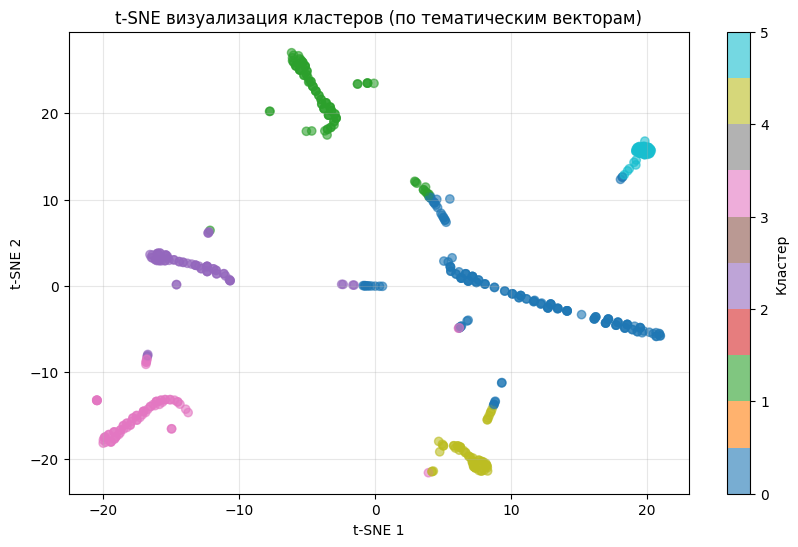

In [ ]:
tsne = TSNE(n_components=2, random_state=42, metric='cosine')
coords = tsne.fit_transform(topic_vectors)
plt.figure(figsize=(10,6))
scatter = plt.scatter(coords[:,0], coords[:,1], c=labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Кластер')
plt.title('t-SNE визуализация кластеров (по тематическим векторам)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(alpha=0.3)
plt.show()

K=2: силуэт = 0.3013
K=3: силуэт = 0.4282
K=4: силуэт = 0.5623
K=5: силуэт = 0.6924
K=6: силуэт = 0.7810
K=7: силуэт = 0.7725
K=8: силуэт = 0.7751
K=9: силуэт = 0.7856

Оптимальное число кластеров по силуэту: 9 (score=0.7856)


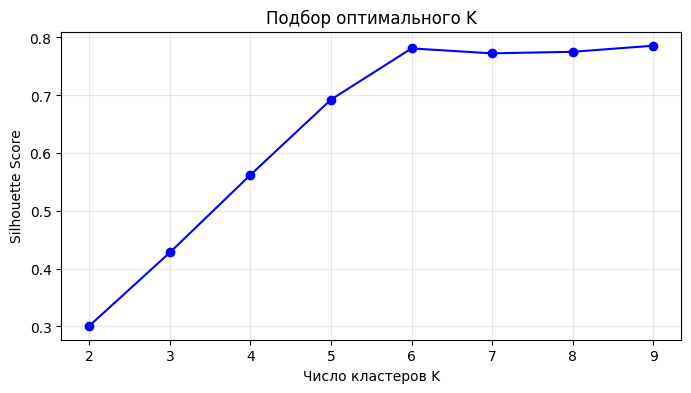

Silhouette: 0.7856
Calinski-Harabasz: 1256.45
Davies-Bouldin: 0.7255

Кластер 0 (размер: 27 документов)
Доминирующие темы LDA в кластере:
  Тема 1 (81.5%): языковой, модель, крупный, chatgpt, область
  Тема 0 (7.4%): модель, языковой, интеллект, искусственный, данные
  Тема 4 (7.4%): область, медицинский, интеллект, искусственный, млм
  Тема 2 (3.7%): область, вопрос, млм, языковой, модель

Примеры статей (первые 3):
  1. Assessing the Utilization of Large Language Models in Medical Education: Insights From Undergraduate Medical Students
     Суммаризация: Искусственный интеллект (AI) может быть интегрирован в медицинское образование. В качестве мощного инструмента появились такие крупные языковые модели (LLMM), как ChATGPT, Google Bard, Microsoft Bing ...
  2. Language models and psychological sciences
     Суммаризация: Крупные языковые модели (LMM) демонстрируют впечатляющие результаты по многим логичным и решающим проблемы задачам когнитивной психологии. При проверке их точность за

In [ ]:
clusterer = DocumentClusterer()
labels = clusterer.fit(topic_vectors)
clusterer.evaluate(topic_vectors)

df_result = df.copy()
df_result['Summary_EN'] = summaries_en
df_result['Summary_RU'] = summaries_ru
df_result['Topic_Vector'] = list(topic_vectors)
df_result['Dominant_Topic'] = np.argmax(topic_vectors, axis=1)

df_result = interpret_clusters(df_result, topic_vectors, labels, topic_modeler, n_examples=3)

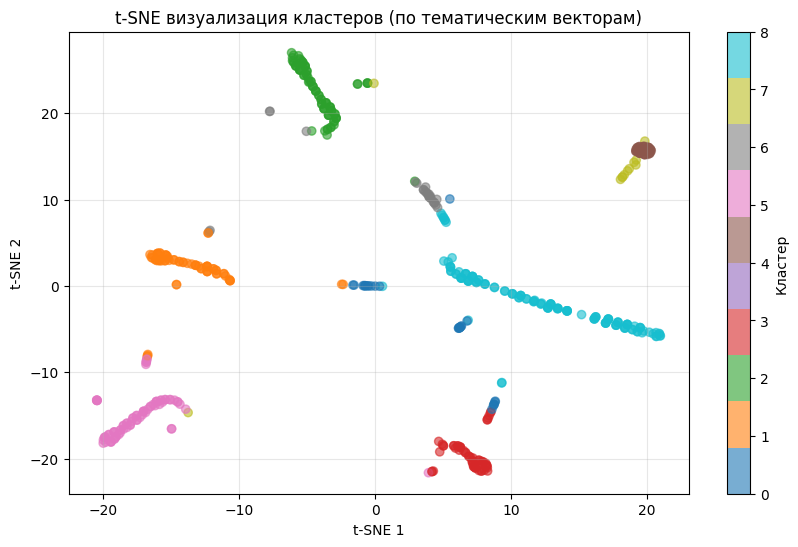

In [ ]:
tsne = TSNE(n_components=2, random_state=42, metric='cosine')
coords = tsne.fit_transform(topic_vectors)
plt.figure(figsize=(10,6))
scatter = plt.scatter(coords[:,0], coords[:,1], c=labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Кластер')
plt.title('t-SNE визуализация кластеров (по тематическим векторам)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(alpha=0.3)
plt.show()